##Setup

In [ ]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [ ]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

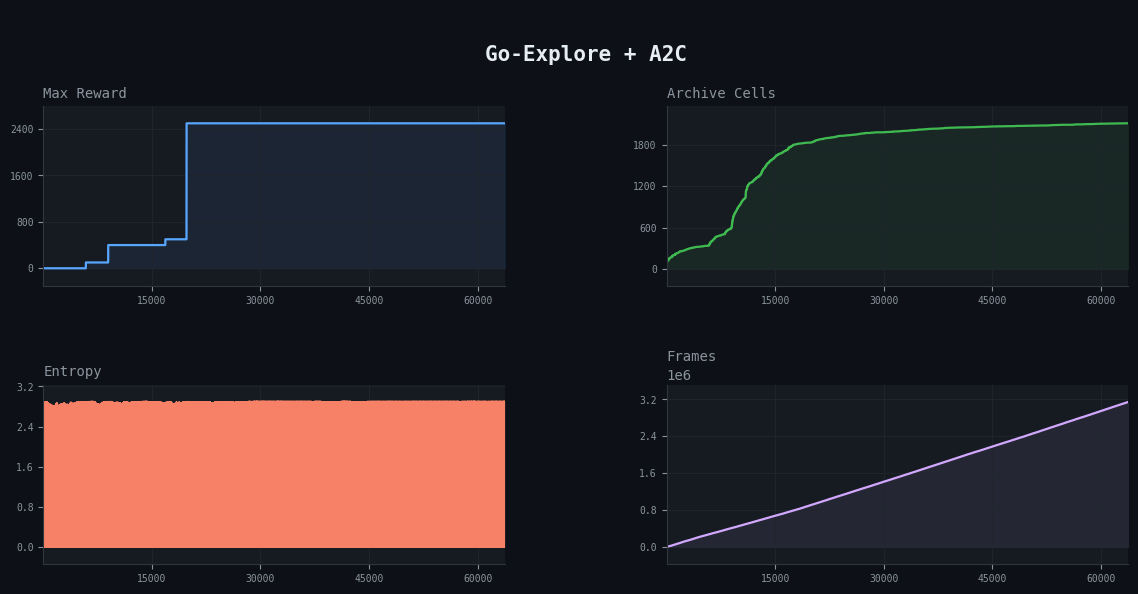

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'entropy', 'frames'],
    title='Go-Explore + A2C',
    update_every=10,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Count-based intrinsic reward
#
# r_intrinsic(s) = β / sqrt(N(s))
#
# where N(s) is how many times the agent has visited the cell
# corresponding to state s, and β is a scaling coefficient.
#
# Why 1/sqrt(N):
#   This is the pseudo-count bonus from Bellemare et al. (2016).
#   A state visited once gets bonus β. A state visited 4 times
#   gets β/2. The bonus decays as sqrt(N), so the policy is
#   continuously nudged toward less-visited regions without
#   the bonus dominating once a state is well-explored.
#
# Critical separation:
#   Intrinsic reward is added to the A2C return computation ONLY.
#   It is NEVER added to `score` or `highscore`, which always
#   reflect true game reward. This ensures the dashboard and
#   archive remain comparable across experiments.
# ──────────────────────────────────────────────
INTRINSIC_BETA = 0.01   # Scale of intrinsic bonus relative to game reward
                        # (game rewards are 0 or multiples of 100;
                        #  0.01 gives a small but non-negligible push
                        #  toward novel cells)

def intrinsic_reward(cell):
    """
    Return β / sqrt(N(s)) where N(s) = cell.times_seen.
    Returns 0 for terminal steps (no cell was visited).
    """
    n = max(cell.times_seen, 1)   # avoid division by zero on first visit
    return INTRINSIC_BETA / (n ** 0.5)


# ──────────────────────────────────────────────
# Networks
# ──────────────────────────────────────────────
class Actor(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            x = F.relu(self.conv1(dummy))
            x = F.relu(self.conv2(x))
            x = F.relu(self.conv3(x))
            self._feature_size = x.reshape(1, -1).size(1)
        self.fc = nn.Linear(self._feature_size, n_actions)

    def forward(self, x):
        x = x.float() / 255.
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        logits = self.fc(x.reshape(x.size(0), -1))
        return F.softmax(logits, dim=-1)


class Critic(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.conv1 = nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride=1)
        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            x = F.relu(self.conv1(dummy))
            x = F.relu(self.conv2(x))
            x = F.relu(self.conv3(x))
            self._feature_size = x.reshape(1, -1).size(1)
        self.fc = nn.Linear(self._feature_size, 1)

    def forward(self, x):
        x = x.float() / 255.
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        return self.fc(x.reshape(x.size(0), -1))


# ──────────────────────────────────────────────
# A2C Agent
# ──────────────────────────────────────────────
class A2CAgent:
    def __init__(self, env, gamma=0.99, lr=1e-4, entropy_coef=0.05, grad_clip=0.5):
        self.env               = env
        self.action_space_size = env.action_space.n
        obs                    = env.observation_space.shape
        self.input_shape       = (obs[2], obs[0], obs[1])

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.actor  = Actor(self.input_shape, self.action_space_size).to(self.device)
        self.critic = Critic(self.input_shape).to(self.device)

        self.actor_optimizer  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)

        self.gamma        = gamma
        self.entropy_coef = entropy_coef
        self.grad_clip    = grad_clip

    def select_action(self, state):
        state_t = torch.from_numpy(state).permute(2, 0, 1).unsqueeze(0).to(self.device)
        probs   = self.actor(state_t)
        dist    = torch.distributions.Categorical(probs)
        action  = dist.sample()
        return action.item(), dist.log_prob(action)

    def compute_returns(self, rewards, dones):
        """
        rewards : list of (extrinsic + intrinsic) combined reward per step.
        The critic learns to predict this combined return; the policy is
        rewarded for visiting novel states as well as earning game points.
        """
        R       = 0.0
        returns = []
        for i in reversed(range(len(rewards))):
            if dones[i]:
                R = 0.0
            R = rewards[i] + self.gamma * R
            returns.insert(0, R)
        return torch.tensor(returns, dtype=torch.float32).to(self.device)

    def update_model(self, states, actions, rewards, dones, policy_mask):
        if len(states) < 2:
            return 0.0, 0.0, 0.0

        states_t  = torch.stack(
            [torch.from_numpy(s).permute(2, 0, 1) for s in states]
        ).to(self.device)
        actions_t = torch.tensor(actions, dtype=torch.long).to(self.device)
        mask_t    = torch.tensor(policy_mask, dtype=torch.bool).to(self.device)

        values  = self.critic(states_t).squeeze(-1)
        returns = self.compute_returns(rewards, dones)

        critic_loss = F.huber_loss(values, returns.detach(), delta=1.0)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), self.grad_clip)
        self.critic_optimizer.step()

        if mask_t.sum() < 2:
            return 0.0, critic_loss.item(), 0.0

        policy_states  = states_t[mask_t]
        policy_actions = actions_t[mask_t]
        policy_returns = returns[mask_t]
        policy_values  = values[mask_t].detach()

        advantages = policy_returns - policy_values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        current_probs = self.actor(policy_states)
        dist          = torch.distributions.Categorical(current_probs)
        log_probs     = dist.log_prob(policy_actions)
        entropy       = dist.entropy().mean()

        actor_loss = -(log_probs * advantages).mean() - self.entropy_coef * entropy

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), self.grad_clip)
        self.actor_optimizer.step()

        return actor_loss.item(), critic_loss.item(), entropy.item()


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
WARMUP_ITERS    = 50
STEPS_PER_ITER  = 100
EXPLORE_EPSILON = 0.5

archive   = defaultdict(lambda: Cell())
highscore = 0
frames    = 0

env   = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
agent = A2CAgent(env)

state, _      = env.reset()
score         = 0
trajectory    = []
iterations    = 0
restore_cell  = None
current_lives = get_lives(env)

# ──────────────────────────────────────────────
# Main loop
# ──────────────────────────────────────────────
while True:
    found_new_cell = False

    episode_states      = []
    episode_actions     = []
    episode_rewards     = []   # combined (extrinsic + intrinsic) — fed to A2C
    episode_dones       = []
    episode_policy_mask = []

    for step in range(STEPS_PER_ITER):
        use_random = iterations < WARMUP_ITERS or random.random() < EXPLORE_EPSILON

        if use_random:
            action    = env.action_space.sample()
            is_policy = False
        else:
            action, _ = agent.select_action(state)
            is_policy = True

        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost
        current_lives = new_lives

        # ── Intrinsic reward ──────────────────────────────────────────────────
        # Computed from the cell the agent just arrived at (next_state).
        # Terminal steps get no intrinsic bonus — there is no next cell to visit.
        # visit() is called FIRST so times_seen reflects this visit when we
        # compute the bonus (first visit → times_seen=1 → max bonus β).
        if not done:
            cell_repr   = cellfn(next_state)
            cellhash    = hashfn(cell_repr)
            cell        = archive[cellhash]
            first_visit = cell.visit()   # increments times_seen

            r_intrinsic = intrinsic_reward(cell)   # β / sqrt(times_seen)

            # ── Archive update ────────────────────────────────────────────────
            cell_reward = getattr(cell, 'reward',     -1e9)
            cell_traj   = getattr(cell, 'trajectory', [])
            better  = score + reward > cell_reward
            shorter = (score + reward == cell_reward and
                       len(trajectory) + 1 < len(cell_traj))

            if first_visit or better or shorter:
                cell.ram        = env.unwrapped.ale.cloneState()
                cell.reward     = score + reward
                cell.trajectory = trajectory + [action]
                cell.times_chosen           = 0
                cell.times_chosen_since_new = 0
                found_new_cell = True
        else:
            r_intrinsic = 0.0   # no bonus on terminal steps

        # ── Score tracking — extrinsic only ──────────────────────────────────
        # score and highscore NEVER include intrinsic reward so the dashboard
        # and archive remain directly comparable across all experiments.
        score += reward
        trajectory.append(action)
        frames += 1

        if score > highscore:
            highscore = score

        episode_states.append(state)
        episode_actions.append(action)
        # Combined reward for A2C: the policy sees novelty bonuses,
        # but the archive and metrics never do.
        episode_rewards.append(reward + r_intrinsic)
        episode_dones.append(done)
        episode_policy_mask.append(is_policy)

        if done:
            score         = 0
            trajectory    = []
            state, _      = env.reset()
            current_lives = get_lives(env)
            break
        else:
            state = next_state

    # ── A2C update ────────────────────────────────────────────────────────────
    if iterations >= WARMUP_ITERS and len(episode_states) > 0:
        actor_loss, critic_loss, entropy = agent.update_model(
            episode_states, episode_actions, episode_rewards,
            episode_dones, episode_policy_mask
        )
    else:
        actor_loss = critic_loss = entropy = 0.0

    if found_new_cell and restore_cell is not None:
        restore_cell.times_chosen_since_new = 0

    iterations += 1

    if len(archive) > 0:
        scores      = np.array([c.score for c in archive.values()])
        hashes      = list(archive.keys())
        probs       = scores / scores.sum()
        chosen_hash = np.random.choice(hashes, p=probs)
        restore_cell = archive[chosen_hash]
        ram, score, trajectory = restore_cell.choose()
        state         = restore_env(env, ram)
        current_lives = get_lives(env)
    else:
        state, _      = env.reset()
        score         = 0
        trajectory    = []
        current_lives = get_lives(env)

    dashboard.update(
        iteration=iterations, frames=frames,
        max_reward=highscore, cells=len(archive), entropy=entropy,
    )